In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

print(ROOT)

/Users/katttmar/Desktop/regresión_logistica


In [2]:
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'numpy'

In [ ]:
import numpy as np
print(np.__version__)
from src.modelo import (
    sigmoid,
    predict_proba,
    logistic_risk,
    logistic_gradient,
    log_likelihood,
    likelihood
)

from src.optimizacion import (
    ajustar_modelo,
    norma_theta
)

from src.simulacion import (
    generar_datos,
    generar_datos_modelo
)

print("Importaciones realizadas correctamente")

2.0.2
Importaciones realizadas correctamente


## Ejercicio 1

In [ ]:
#Datos

x = np.array([
    -2, -1.5, -1, -0.5, 0,
    0.5, 1, 1.5, 2
])

y = np.array([
    0, 0, 0, 1, 0,
    1, 1, 1, 1
])

In [ ]:
#Calculo del riesgo

theta0 = np.linspace(-4, 4, 100)
theta1 = np.linspace(-1, 6, 100)

Theta0, Theta1 = np.meshgrid(theta0, theta1)

R = np.zeros_like(Theta0)

for i in range(Theta0.shape[0]):
    for j in range(Theta0.shape[1]):
        theta = np.array([Theta0[i, j], Theta1[i, j]])
        R[i, j] = logistic_risk(theta, x, y)

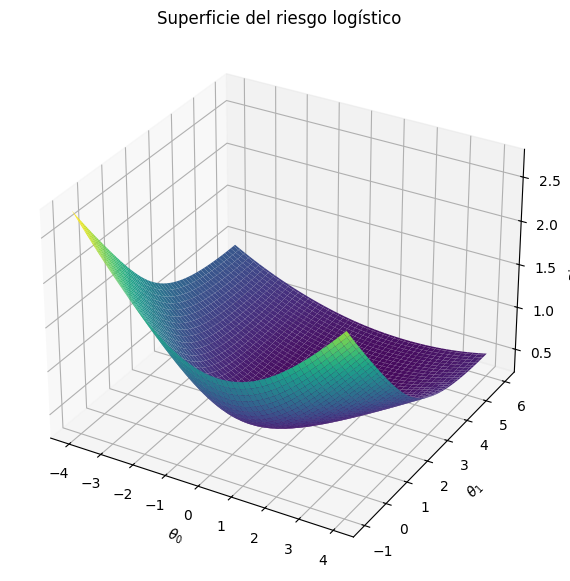

In [ ]:
#Superficie 3d

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    Theta0,
    Theta1,
    R,
    cmap="viridis",
    edgecolor="none"
)

ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel("Riesgo")

ax.set_title("Superficie del riesgo logístico")

plt.show()

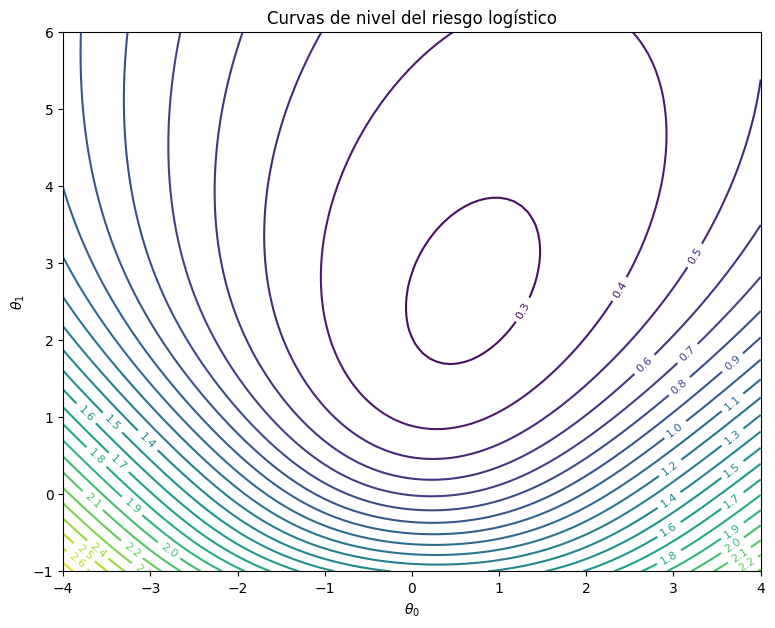

In [ ]:
#Curvas de nivel del riesgo logístico

plt.figure(figsize=(9, 7))

contorno = plt.contour(
    Theta0,
    Theta1,
    R,
    levels=30
)

plt.clabel(contorno, inline=True, fontsize=8)

plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Curvas de nivel del riesgo logístico")

plt.show()

In [ ]:
#Optimización del riesgo logístico


resultado = ajustar_modelo(
    x,
    y,
    theta_inicial=(0, 0)
)

theta_hat = resultado.x
riesgo_minimo = resultado.fun

print("Theta estimado:", theta_hat)
print("Riesgo mínimo:", riesgo_minimo)
print("¿La optimización convergió?", resultado.success)
print("Mensaje:", resultado.message)

Theta estimado: [0.65000891 2.58448729]
Riesgo mínimo: 0.2784542389233234
¿La optimización convergió? True
Mensaje: Optimization terminated successfully.


In [ ]:
#Comprobación del mínimo

riesgo_theta = logistic_risk(theta_hat, x, y)

riesgo_theta0 = logistic_risk(
    theta_hat + np.array([0.1, 0]),
    x,
    y
)

riesgo_theta1 = logistic_risk(
    theta_hat + np.array([0, 0.1]),
    x,
    y
)

print("R(theta_hat) =", riesgo_theta)
print("R(theta_hat + (0.1, 0)) =", riesgo_theta0)
print("R(theta_hat + (0, 0.1)) =", riesgo_theta1)

print()
print(
    "¿Aumenta el riesgo al cambiar theta0?",
    riesgo_theta0 > riesgo_theta
)

print(
    "¿Aumenta el riesgo al cambiar theta1?",
    riesgo_theta1 > riesgo_theta
)

R(theta_hat) = 0.2784542389233234
R(theta_hat + (0.1, 0)) = 0.2788813439799982
R(theta_hat + (0, 0.1)) = 0.27866459114450204

¿Aumenta el riesgo al cambiar theta0? True
¿Aumenta el riesgo al cambiar theta1? True


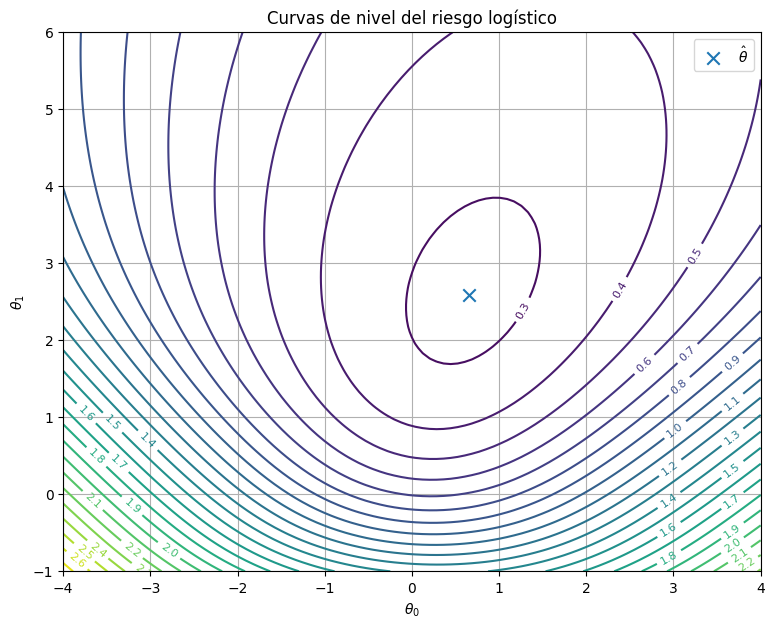

In [ ]:
#Grafica con el mínimo marcado

plt.figure(figsize=(9, 7))

contorno = plt.contour(
    Theta0,
    Theta1,
    R,
    levels=30
)

plt.clabel(
    contorno,
    inline=True,
    fontsize=8
)

plt.scatter(
    theta_hat[0],
    theta_hat[1],
    s=80,
    marker="x",
    label=r"$\hat{\theta}$"
)

plt.xlabel(r"$\theta_0$")
plt.ylabel(r"$\theta_1$")
plt.title("Curvas de nivel del riesgo logístico")

plt.legend()
plt.grid(True)

plt.savefig(
    "../resultados/contorno_riesgo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

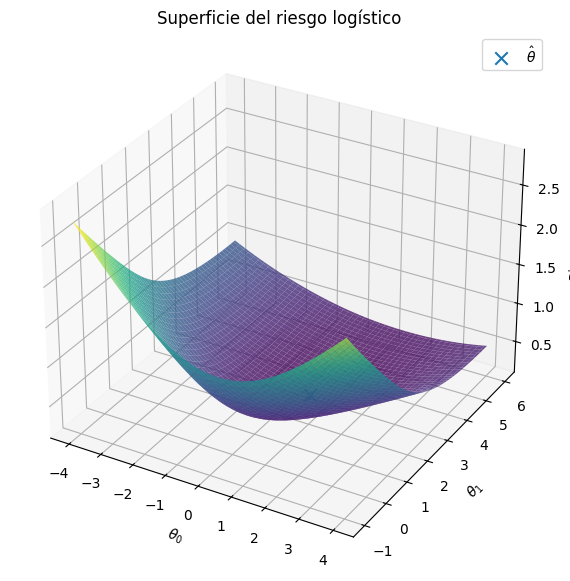

In [ ]:
#Gráfica 3d con el mínimo marcado

fig = plt.figure(figsize=(10, 7))

ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    Theta0,
    Theta1,
    R,
    cmap="viridis",
    edgecolor="none",
    alpha=0.8
)

ax.scatter(
    theta_hat[0],
    theta_hat[1],
    riesgo_minimo,
    s=80,
    marker="x",
    label=r"$\hat{\theta}$"
)

ax.set_xlabel(r"$\theta_0$")
ax.set_ylabel(r"$\theta_1$")
ax.set_zlabel("Riesgo")

ax.set_title("Superficie del riesgo logístico")

ax.legend()

plt.savefig(
    "../resultados/superficie_riesgo.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

### Interpretación del resultado

La optimización iniciada en $(0,0)$ encontró el estimador

$$
\hat{\theta}=(0.65000891,\;2.58448729).
$$

El riesgo logístico mínimo obtenido fue

$$
R(\hat{\theta})=0.2784542389.
$$

La optimización terminó exitosamente. Además, al modificar cada componente de $\hat{\theta}$ en $0.1$, el riesgo aumenta:

$$
R(\hat{\theta}) < R(\hat{\theta}+(0.1,0))
$$

y

$$
R(\hat{\theta}) < R(\hat{\theta}+(0,0.1)).
$$

Esto es consistente con que $\hat{\theta}$ corresponde a un mínimo del riesgo en la región analizada.

## Ejercicio 2

In [ ]:
#Conjuto de datos

y_A = np.array([
    0, 0, 0, 0, 1,
    1, 1, 1, 1
])

y_B = np.array([
    0, 0, 0, 1, 0,
    1, 1, 1, 1
])

In [ ]:
#Ajuste para A y B

resultado_A = ajustar_modelo(
    x,
    y_A,
    theta_inicial=(0, 0)
)

resultado_B = ajustar_modelo(
    x,
    y_B,
    theta_inicial=(0, 0)
)

theta_A = resultado_A.x
theta_B = resultado_B.x

riesgo_A = resultado_A.fun
riesgo_B = resultado_B.fun

print("Conjunto A")
print("Theta:", theta_A)
print("Riesgo:", riesgo_A)

print()

print("Conjunto B")
print("Theta:", theta_B)
print("Riesgo:", riesgo_B)

Conjunto A
Theta: [ 9.41654849 42.00534617]
Riesgo: 1.00730195437342e-05

Conjunto B
Theta: [0.65000891 2.58448729]
Riesgo: 0.2784542389233234


In [ ]:
#Normas de los parámetros estimados

norma_A = norma_theta(theta_A)
norma_B = norma_theta(theta_B)

print("Norma theta A:", norma_A)
print("Norma theta B:", norma_B)

Norma theta A: 43.047886041551926
Norma theta B: 2.6649739470505813


In [ ]:
#Tabbla
print("Conjunto | Norma theta | Riesgo")
print("----------------------------------")
print(f"A        | {norma_A:.6f}    | {riesgo_A:.6f}")
print(f"B        | {norma_B:.6f}    | {riesgo_B:.6f}")

Conjunto | Norma theta | Riesgo
----------------------------------
A        | 43.047886    | 0.000010
B        | 2.664974    | 0.278454


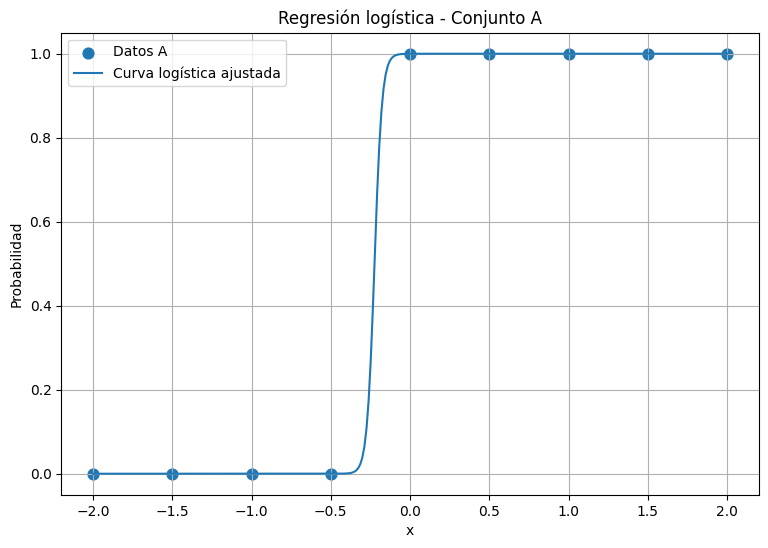

In [ ]:
#Gráfico y Curva de A

x_plot = np.linspace(-2, 2, 300)

p_A = predict_proba(theta_A, x_plot)

plt.figure(figsize=(9, 6))

plt.scatter(
    x,
    y_A,
    s=60,
    label="Datos A"
)

plt.plot(
    x_plot,
    p_A,
    label="Curva logística ajustada"
)

plt.xlabel("x")
plt.ylabel("Probabilidad")
plt.title("Regresión logística - Conjunto A")

plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()

plt.savefig(
    "../resultados/logistica_conjunto_A.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

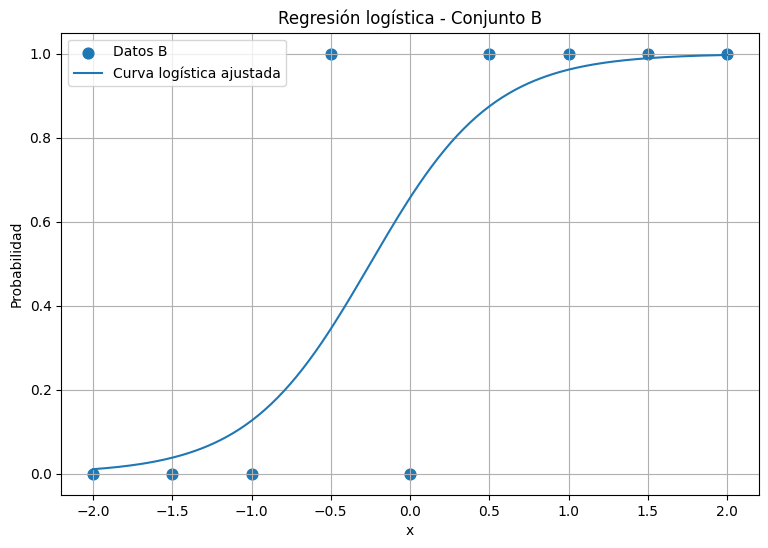

In [ ]:
#Gráfica y CUrva de B

p_B = predict_proba(theta_B, x_plot)

plt.figure(figsize=(9, 6))

plt.scatter(
    x,
    y_B,
    s=60,
    label="Datos B"
)

plt.plot(
    x_plot,
    p_B,
    label="Curva logística ajustada"
)

plt.xlabel("x")
plt.ylabel("Probabilidad")
plt.title("Regresión logística - Conjunto B")

plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()

plt.savefig(
    "../resultados/logistica_conjunto_B.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Conjunto A separable

resultado_A_10 = ajustar_modelo(
    x,
    y_A,
    theta_inicial=(0, 0),
    maxiter=10
)

resultado_A_100 = ajustar_modelo(
    x,
    y_A,
    theta_inicial=(0, 0),
    maxiter=100
)

In [ ]:
#Normas y riesgos

theta_A_10 = resultado_A_10.x
theta_A_100 = resultado_A_100.x

norma_A_10 = norma_theta(theta_A_10)
norma_A_100 = norma_theta(theta_A_100)

riesgo_A_10 = resultado_A_10.fun
riesgo_A_100 = resultado_A_100.fun

print("maxiter = 10")
print("Theta:", theta_A_10)
print("Norma:", norma_A_10)
print("Riesgo:", riesgo_A_10)

print()

print("maxiter = 100")
print("Theta:", theta_A_100)
print("Norma:", norma_A_100)
print("Riesgo:", riesgo_A_100)

maxiter = 10
Theta: [ 3.33027623 15.67719692]
Norma: 16.02701604014122
Riesgo: 0.0051258905795569625

maxiter = 100
Theta: [ 9.41654849 42.00534617]
Norma: 43.047886041551926
Riesgo: 1.00730195437342e-05


In [ ]:
#Comparación

print("Comparación para el conjunto A")
print("--------------------------------")
print(f"maxiter=10   | Norma = {norma_A_10:.6f} | Riesgo = {riesgo_A_10:.6f}")
print(f"maxiter=100  | Norma = {norma_A_100:.6f} | Riesgo = {riesgo_A_100:.6f}")


Comparación para el conjunto A
--------------------------------
maxiter=10   | Norma = 16.027016 | Riesgo = 0.005126
maxiter=100  | Norma = 43.047886 | Riesgo = 0.000010


## Interpretación del Ejercicio 2

El conjunto A es separable mediante un umbral en x, mientras que el conjunto B no es separable.

Para cada conjunto se ajustó un modelo de regresión logística utilizando la misma función de optimización. Se compararon la norma euclídea de los parámetros estimados y el riesgo logístico.

En el caso del conjunto A, al aumentar el número máximo de iteraciones de 10 a 100 se observa el comportamiento de los parámetros y del riesgo asociado al carácter separable de los datos.

Los resultados numéricos obtenidos se muestran en las tablas anteriores y las curvas logísticas ajustadas se presentan en las figuras guardadas en la carpeta `resultados/`.

## Ejercicio 3

In [ ]:
#Parámetros verdaderos

theta_real = np.array([-1, 2])

tamaños_muestra = [50, 200, 1000]

In [3]:
#Datos y ajuste del modelo

resultados_ej3 = []

for n in tamaños_muestra:

    x_n, y_n = generar_datos_modelo(
        n,
        seed=2026
    )

    resultado = ajustar_modelo(
        x_n,
        y_n,
        theta_inicial=(0, 0)
    )

    theta_n = resultado.x

    error_n = norma_theta(
        theta_n - theta_real
    )

    resultados_ej3.append(
        (n, theta_n[0], theta_n[1], error_n)
    )

NameError: name 'tamaños_muestra' is not defined

In [ ]:
#Construcción de la Tabla

print("n    theta_0        theta_1        error")
print("---------------------------------------------")

for n, theta0_n, theta1_n, error_n in resultados_ej3:
    print(
        f"{n:<4} "
        f"{theta0_n:>12.6f} "
        f"{theta1_n:>12.6f} "
        f"{error_n:>12.6f}"
    )

n    theta_0        theta_1        error
---------------------------------------------
50      -1.613777     2.684448     0.919343
200     -0.817836     1.846387     0.238287
1000    -0.964944     1.870623     0.134042


In [ ]:
#Menor error

errores = {
    n: error_n
    for n, theta0_n, theta1_n, error_n in resultados_ej3
}

n_menor_error = min(
    errores,
    key=errores.get
)

print("Error para n=50:", errores[50])
print("Error para n=200:", errores[200])
print("Error para n=1000:", errores[1000])

print()
print("Tamaño muestral con menor error:", n_menor_error)

print(
    "¿Se cumple e_1000 < e_50?",
    errores[1000] < errores[50]
)

Error para n=50: 0.9193428918151505
Error para n=200: 0.23828688989623714
Error para n=1000: 0.13404189025192548

Tamaño muestral con menor error: 1000
¿Se cumple e_1000 < e_50? True


### Conclusión

El menor error se obtuvo para $n=1000$, con

$$
e_{1000}=0.134042.
$$

Además, se verifica que

$$
e_{1000}<e_{50},
$$

ya que

$$
0.134042 < 0.919343.
$$

En estos experimentos, al aumentar el tamaño de la muestra de 50 a 1000 observaciones, el error de recuperación del parámetro verdadero disminuyó.

## Ejercicio 4

### (a) Frontera de decisión

Partimos del modelo

$$
p_\theta(x)=\sigma(\theta_0+\theta_1x)
$$

donde

$$
\sigma(t)=\frac{1}{1+e^{-t}}.
$$

Queremos encontrar los valores de $x$ para los cuales

$$
p_\theta(x)=\frac{1}{2}.
$$

Entonces:

$$
\frac{1}{1+e^{-(\theta_0+\theta_1x)}}=\frac{1}{2}.
$$

Multiplicando:

$$
2=1+e^{-(\theta_0+\theta_1x)}.
$$

Por lo tanto:

$$
e^{-(\theta_0+\theta_1x)}=1.
$$

Como $e^t=1$ solamente cuando $t=0$:

$$
-(\theta_0+\theta_1x)=0.
$$

Así,

$$
\theta_0+\theta_1x=0.
$$

Si $\theta_1\neq0$, despejamos $x$:

$$
\boxed{x=-\frac{\theta_0}{\theta_1}}.
$$

Por tanto,

$$
\boxed{
p_\theta(x)=\frac12
\iff
x=-\frac{\theta_0}{\theta_1}
}.
$$

### (b) Variar theta0

In [ ]:
#Valores de x

x_plot = np.linspace(-6, 6, 500)
theta1 = 1

theta0_valores = [-2, 0, 2]

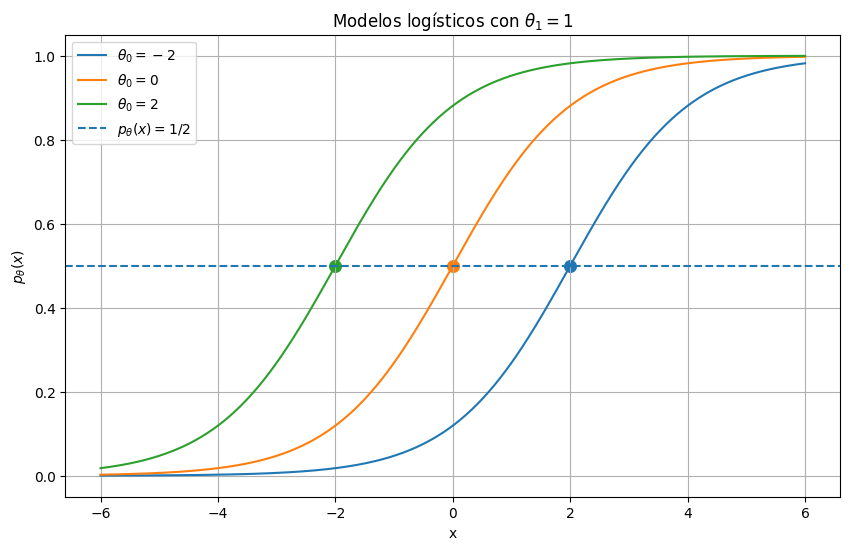

In [ ]:
#Curvas

plt.figure(figsize=(10, 6))

for theta0 in theta0_valores:

    theta = np.array([theta0, theta1])

    probabilidades = predict_proba(
        theta,
        x_plot
    )

    x_frontera = -theta0 / theta1

    plt.plot(
        x_plot,
        probabilidades,
        label=rf"$\theta_0={theta0}$"
    )

    plt.scatter(
        x_frontera,
        0.5,
        s=70
    )

plt.axhline(
    0.5,
    linestyle="--",
    label=r"$p_\theta(x)=1/2$"
)

plt.xlabel("x")
plt.ylabel(r"$p_\theta(x)$")
plt.title(r"Modelos logísticos con $\theta_1=1$")

plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()

plt.savefig(
    "../resultados/interpretacion_theta0.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#fronteras

print("theta_0    theta_1    x*          p(x*)")
print("--------------------------------------------")

for theta0 in theta0_valores:

    x_frontera = -theta0 / theta1

    theta = np.array([
        theta0,
        theta1
    ])

    p_frontera = predict_proba(
        theta,
        x_frontera
    )

    print(
        f"{theta0:>7} "
        f"{theta1:>9} "
        f"{x_frontera:>9.2f} "
        f"{p_frontera:>12.6f}"
    )

theta_0    theta_1    x*          p(x*)
--------------------------------------------
     -2         1      2.00     0.500000
      0         1      0.00     0.500000
      2         1     -2.00     0.500000


### (c) variar theta1

In [ ]:
#Valores

theta0 = 0
theta1_valores = [1, 2, 5]

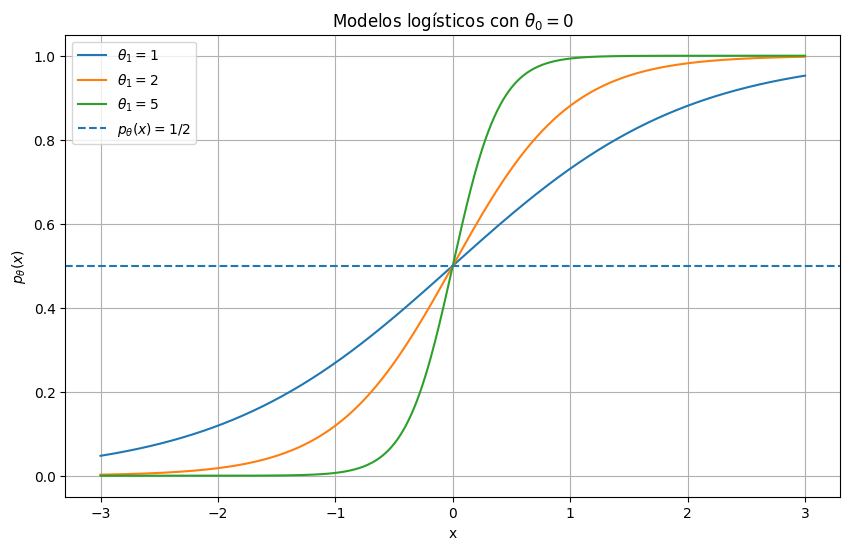

In [ ]:
#Curvas

x_plot = np.linspace(-3, 3, 500)

plt.figure(figsize=(10, 6))

for theta1 in theta1_valores:

    theta = np.array([
        theta0,
        theta1
    ])

    probabilidades = predict_proba(
        theta,
        x_plot
    )

    plt.plot(
        x_plot,
        probabilidades,
        label=rf"$\theta_1={theta1}$"
    )

plt.axhline(
    0.5,
    linestyle="--",
    label=r"$p_\theta(x)=1/2$"
)

plt.xlabel("x")
plt.ylabel(r"$p_\theta(x)$")
plt.title(r"Modelos logísticos con $\theta_0=0$")

plt.ylim(-0.05, 1.05)
plt.grid(True)
plt.legend()

plt.savefig(
    "../resultados/interpretacion_theta1.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
#Calculo p(1)-p(-1)

print("theta_1    p(1)        p(-1)       p(1)-p(-1)")
print("------------------------------------------------")

for theta1 in theta1_valores:

    theta = np.array([
        theta0,
        theta1
    ])

    p_1 = predict_proba(
        theta,
        1
    )

    p_menos_1 = predict_proba(
        theta,
        -1
    )

    diferencia = p_1 - p_menos_1

    print(
        f"{theta1:>7} "
        f"{p_1:>11.6f} "
        f"{p_menos_1:>11.6f} "
        f"{diferencia:>14.6f}"
    )

theta_1    p(1)        p(-1)       p(1)-p(-1)
------------------------------------------------
      1    0.731059    0.268941       0.462117
      2    0.880797    0.119203       0.761594
      5    0.993307    0.006693       0.986614


### Interpretación

Al fijar $\theta_0=0$ y aumentar $\theta_1$, cambia la pendiente de la función logística.

La cantidad

$$
p_\theta(1)-p_\theta(-1)
$$

permite cuantificar cuánto cambia la probabilidad entre $x=-1$ y $x=1$.

Los valores calculados muestran que la diferencia aumenta al incrementar $\theta_1$. Por lo tanto, entre los modelos considerados, el correspondiente al mayor valor de $\theta_1$ presenta la transición más abrupta. Así entre mayor sea p(1) y menor sea p(-1), la diferencia aumenta

## Ejercicio 5

In [ ]:
#Funciones

import numpy as np

from src.simulacion import generar_datos_modelo
from src.modelo import (
    likelihood,
    log_likelihood,
    logistic_risk
)

In [ ]:
#Datos

n = 5000

x, y = generar_datos_modelo(n, seed=2026)

theta_star = np.array([-1.0, 2.0])

### (a) Calculo

In [ ]:
#Calculo

L = likelihood(theta_star, x, y)

log_L = log_likelihood(theta_star, x, y)

print("L(theta*):", L)
print("log L(theta*):", log_L)

L(theta*): 0.0
log L(theta*): -1954.920071716625


### (b) Edtabilidad

In [ ]:
print("Verosimilitud:", L)
print("Log-verosimilitud:", log_L)

print("\n¿L(theta*) es finita?:", np.isfinite(L))
print("¿log L(theta*) es finita?:", np.isfinite(log_L))

Verosimilitud: 0.0
Log-verosimilitud: -1954.920071716625

¿L(theta*) es finita?: True
¿log L(theta*) es finita?: True


### (c) Riesgo empírico

In [ ]:
R = logistic_risk(theta_star, x, y)

Delta = abs(
    -log_L - n * R
)

print("Riesgo empírico:", R)
print("Delta:", Delta)

Riesgo empírico: 0.39098401434332497
Delta: 2.2737367544323206e-13
